# Day 26: Understanding and Implementing k-Nearest Neighbors (k-NN)

---
## Objectives:

- Comprehend the fundamentals of **k-Nearest Neighbors (k-NN)**.
- Understand the concept of **non-parametric models**.
- Implement k-NN classification from scratch.
- Apply the k-NN algorithm to a real-world dataset.
- Utilize robust visualizations to interpret results.

---

## 1. Introduction to k-Nearest Neighbors (k-NN)

**k-Nearest Neighbors (k-NN)** is a simple, non-parametric, and lazy learning algorithm used for both classification and regression tasks. It operates on the principle that similar data points exist in close proximity.

**Key Characteristics:**
- **Non-Parametric:** k-NN doesn't assume any underlying data distribution.
- **Lazy Learning:** It doesn't learn a discriminative function from the training data but memorizes the dataset instead.

---

## 2. How Does k-NN Work?

1. **Select the Number of Neighbors (k):** Decide the number of nearest neighbors to consider for classification or regression.
2. **Compute Distance:** Calculate the distance between the query point and all points in the training data using a distance metric (e.g., Euclidean distance).
3. **Identify Neighbors:** Select the k data points that are closest to the query point.
4. **Vote or Average:**
   - **Classification:** Assign the class most common among the k neighbors.
   - **Regression:** Compute the average of the k neighbors' values.

---

## 3. Advantages and Disadvantages of k-NN

**Advantages:**
- **Simplicity:** Easy to understand and implement.
- **No Training Phase:** Useful for applications where training is computationally expensive.

**Disadvantages:**
- **Computational Cost:** High memory usage and prediction time, especially with large datasets.
- **Sensitivity to Irrelevant Features:** Performance can degrade with irrelevant or redundant features.

---

## 4. Dataset Overview

We'll use the **Breast Cancer Wisconsin Dataset**, which includes:

- **Features:** Various measurements of cell nuclei present in breast cancer biopsies.
- **Target:** Classification of tumors as malignant or benign.

---

## 5. Data Loading and Exploration

In [23]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)

In [3]:
#Display the first few rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df['target'] = data.target

## 6. Data Preprocessing


In [6]:
#Check for missing values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [7]:
#Feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('target', axis=1))
df_scaled = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_scaled['target'] = df['target']

## 7. Train Test Split

In [9]:
#Split the data
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Implementing k-NN from Scratch

In [10]:
#function to calculate Euclidean distance
def euclidean_distance(a,b):
    return np.sqrt(np.sum((a-b) ** 2))

In [11]:
#Function to get k nearest neighbors
def get_neighbors(X_train, y_train, test_instance,k):
    distances = []
    for i in range(len(X_train)):
        dist=euclidean_distance(X_train.iloc[i], test_instance)
        distances.append((X_train.iloc[i], y_train.iloc[i], dist))
    distances.sort(key=lambda x: x[2])
    neighbors = distances[:k]
    return neighbors

In [12]:
# Funciton to predict class
def predict_classification(X_train, y_train, test_instance, k):
    neighbors = get_neighbors(X_train, y_train, test_instance, k)
    output_values = [neighbor[1] for neighbor in neighbors]
    prediction = max(set(output_values), key=output_values.count)
    return prediction

## 9. Model Training and Prediction

In [13]:
#Set the value of k
k = 5

In [14]:
#Predict on the test set
predictions = []
for i in range(len(X_test)):
    pred = predict_classification(X_train, y_train, X_test.iloc[i], k)
    predictions.append(pred)
    

## 10. Model Evaluation


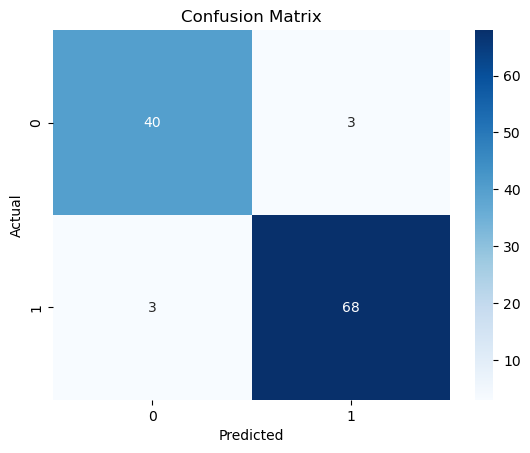

In [15]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
#Classification report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 11. Visualization

In [17]:
#Select two features for visualization
X_vis = df_scaled[['mean radius', 'mean texture']]
y_vis = df_scaled['target']

In [18]:
#Train test split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.2, random_state=42)


In [38]:
#Plot the decision boundary
def plot_decision_boundary(X,y,model,k):
    h = .02
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx ,yy = np.meshgrid(np.arange(x_min, x_max, h), 
                         np.arange(y_min, y_max, h))
    
    #Predict Over mesh grid points
    Z = model.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns))
    Z = Z.reshape(xx.shape)

    #Plot decision boundary
    plt.figure(figsize=(10,6))
    plt.contour(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.xlabel('Mean Radius')
    plt.ylabel('Mean Texture')
    plt.title(f'k-NN Decision boundary (k={k})')
    plt.show()

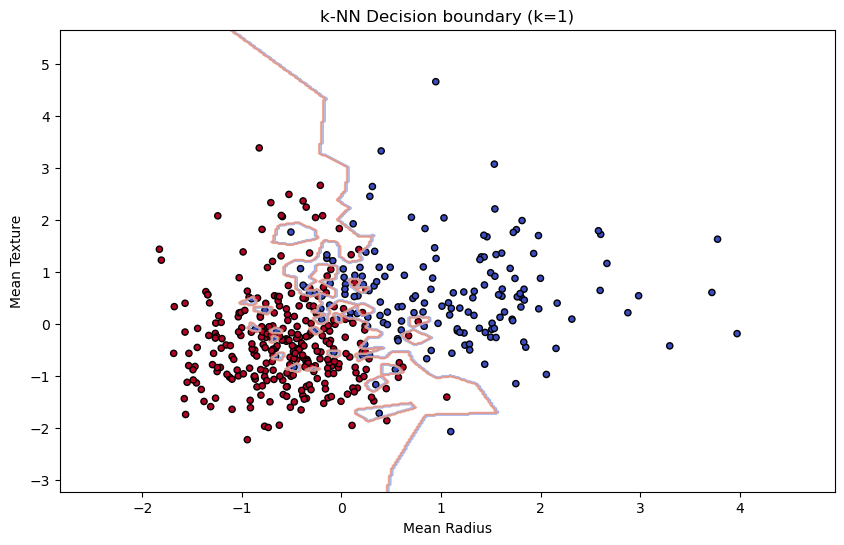

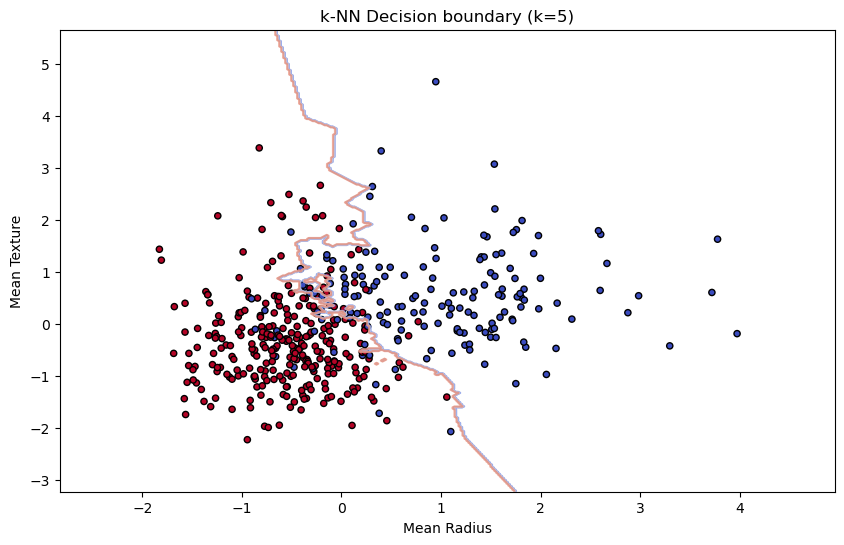

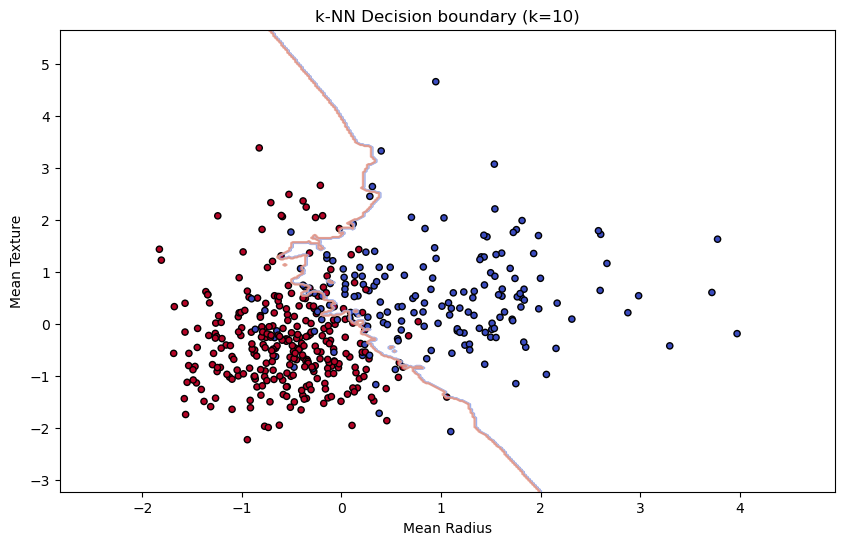

In [39]:
#Plot decision boundaries for different values of k
for k in [1, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_vis, y_train_vis)
    plot_decision_boundary(X_train_vis, y_train_vis, knn, k)

## 12. Conclusion
- **k-NN Fundamentals:** We explored the basics of the k-Nearest Neighbors algorithm, understanding its non-parametric and lazy learning nature.
- **Implementation:** Implemented k-NN from scratch and applied it to the Breast Cancer Wisconsin Dataset.
- **Visualization:** Visualized decision boundaries to comprehend how k-NN classifies data points based on different values of k.
- **Evaluation:** Assessed the model's performance using confusion matrices and classification reports.